<a href="https://colab.research.google.com/github/farkhad-gazizov/educational/blob/main/%D0%94%D0%BE%D0%BC%D0%B0%D1%88%D0%BD%D0%B5%D0%B5_%D0%B7%D0%B0%D0%B4%D0%B0%D0%BD%D0%B8%D0%B5_%D0%BA_%D0%BB%D0%B5%D0%BA%D1%86%D0%B8%D0%B8_%C2%AB%D0%9F%D1%80%D0%BE%D0%B4%D0%B2%D0%B8%D0%BD%D1%83%D1%82%D1%8B%D0%B9_pandas%C2%BB.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Домашнее задание к лекции «Продвинутый pandas»

**Задание 1**

Для датафрейма `log` из материалов занятия создайте столбец `source_type` по правилам:

*   если источник `traffic_source` равен Yandex или Google, то в `source_type` ставится `organic`;
*   для источников paid и email из России ставим `ad`;
*   для источников paid и email не из России ставим `other`;
*   все остальные варианты берём из `traffic_source` без изменений.


In [ ]:
import pandas as pd
visit_log = pd.read_csv('visit_log.csv', sep=';')
visit_log.head()

,timestamp,visit_id,url,region,user_id,traffic_source
0,1549980692,e3b0c44298,https://host.ru/3c19b4ef7371864fa3,Russia,b1613cc09f,yandex
1,1549980704,6e340b9cff,https://host.ru/c8d9213a31839f9a3a,Russia,4c3ec14bee,direct
2,1549980715,96a296d224,https://host.ru/b8b58337d272ee7b15,Russia,a8c40697fb,yandex
3,1549980725,709e80c884,https://host.ru/b8b58337d272ee7b15,Russia,521ac1d6a0,yandex
4,1549980736,df3f619804,https://host.ru/b8b58337d272ee7b15,Russia,d7323c571c,yandex


In [ ]:
# условия записи значений во вновь создаваемый столбец source_type
organic = visit_log.traffic_source.isin(['yandex', 'google'])

ad_russia = (visit_log.traffic_source.isin(['paid', 'email'])) & \
            (visit_log.region == 'Russia')

ad_not_russia = (visit_log.traffic_source.isin(['paid', 'email'])) & \
                (visit_log.region != 'Russia')

In [ ]:
#применяем условия
visit_log.loc[organic, 'source_type'] = 'organic'

visit_log.loc[ad_russia, 'source_type'] = 'ad'

visit_log.loc[ad_not_russia, 'source_type'] = 'other'

visit_log.head(20)

,timestamp,visit_id,url,region,user_id,traffic_source,source_type
0,1549980692,e3b0c44298,https://host.ru/3c19b4ef7371864fa3,Russia,b1613cc09f,yandex,organic
1,1549980704,6e340b9cff,https://host.ru/c8d9213a31839f9a3a,Russia,4c3ec14bee,direct,NaN
2,1549980715,96a296d224,https://host.ru/b8b58337d272ee7b15,Russia,a8c40697fb,yandex,organic
3,1549980725,709e80c884,https://host.ru/b8b58337d272ee7b15,Russia,521ac1d6a0,yandex,organic
4,1549980736,df3f619804,https://host.ru/b8b58337d272ee7b15,Russia,d7323c571c,yandex,organic
5,1549980742,8855508aad,https://host.ru/df646c3676cc259fa0,Russia,fc43898e47,yandex,organic
6,1549980742,b0f66adc83,https://host.ru/b8b58337d272ee7b15,Russia,13fc55e781,paid,ad
7,1549980754,837885c8f8,https://host.ru/108ce4b365afb7b88e,Russia,cb5082b6f6,direct,NaN
8,1549980760,af5570f5a1,https://host.ru/3004a8273caeef2867,China,45664f7af2,direct,NaN
9,1549980765,3e7077fd2f,https://host.ru/df646c3676cc259fa0,Russia,6f9de8c8b6,email,ad


In [ ]:
# все остальные варианты из traffic_source переносим в source_type без изменений
visit_log.source_type = visit_log.source_type.fillna(visit_log.traffic_source)
visit_log.head(20)

,timestamp,visit_id,url,region,user_id,traffic_source,source_type
0,1549980692,e3b0c44298,https://host.ru/3c19b4ef7371864fa3,Russia,b1613cc09f,yandex,organic
1,1549980704,6e340b9cff,https://host.ru/c8d9213a31839f9a3a,Russia,4c3ec14bee,direct,direct
2,1549980715,96a296d224,https://host.ru/b8b58337d272ee7b15,Russia,a8c40697fb,yandex,organic
3,1549980725,709e80c884,https://host.ru/b8b58337d272ee7b15,Russia,521ac1d6a0,yandex,organic
4,1549980736,df3f619804,https://host.ru/b8b58337d272ee7b15,Russia,d7323c571c,yandex,organic
5,1549980742,8855508aad,https://host.ru/df646c3676cc259fa0,Russia,fc43898e47,yandex,organic
6,1549980742,b0f66adc83,https://host.ru/b8b58337d272ee7b15,Russia,13fc55e781,paid,ad
7,1549980754,837885c8f8,https://host.ru/108ce4b365afb7b88e,Russia,cb5082b6f6,direct,direct
8,1549980760,af5570f5a1,https://host.ru/3004a8273caeef2867,China,45664f7af2,direct,direct
9,1549980765,3e7077fd2f,https://host.ru/df646c3676cc259fa0,Russia,6f9de8c8b6,email,ad


In [ ]:
# NaN отсутствует, все нормально
visit_log.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18938 entries, 0 to 18937
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   timestamp       18938 non-null  int64 
 1   visit_id        18938 non-null  object
 2   url             18938 non-null  object
 3   region          18938 non-null  object
 4   user_id         18938 non-null  object
 5   traffic_source  18938 non-null  object
 6   source_type     18938 non-null  object
dtypes: int64(1), object(6)
memory usage: 1.0+ MB


**Задание 2**

В файле `URLs.txt` содержатся URL страниц новостного сайта. Вам нужно отфильтровать его по адресам страниц с текстами новостей. Известно, что шаблон страницы новостей имеет внутри URL конструкцию: `/, затем 8 цифр, затем дефис`. Выполните действия:

Прочитайте содержимое файла с датафрейм.
Отфильтруйте страницы с текстом новостей, используя метод str.contains и регулярное выражение в соответствие с заданным шаблоном.

In [ ]:
urls = pd.read_csv('URLs.txt')
urls

,url
0,/world/
1,/latest/
2,/?updated=top
3,/politics/36188461-s-marta-zhizn-rossiyan-susc...
4,/world/36007585-tramp-pridumal-kak-reshit-ukra...
...,...
88,/cis/35984145-kreml-prokommentiroval-soobschen...
89,/video/36071019-olimpiyskie-obekty-rio-prevrat...
90,/science/36151301-nazvano-posledstvie-zloupotr...
91,/incidents/36027330-vospitatelnitsu-zatravili-...


In [ ]:
urls = urls[urls.url.str.contains(r'/\d{8}-')]
urls

,url
3,/politics/36188461-s-marta-zhizn-rossiyan-susc...
4,/world/36007585-tramp-pridumal-kak-reshit-ukra...
5,/science/36157853-nasa-sobiraet-ekstrennuyu-pr...
6,/video/36001498-poyavilis-pervye-podrobnosti-g...
7,/world/36007585-tramp-pridumal-kak-reshit-ukra...
...,...
88,/cis/35984145-kreml-prokommentiroval-soobschen...
89,/video/36071019-olimpiyskie-obekty-rio-prevrat...
90,/science/36151301-nazvano-posledstvie-zloupotr...
91,/incidents/36027330-vospitatelnitsu-zatravili-...


**Задание 3**

Используйте файл с оценками фильмов `ml-latest-small/ratings.csv`. Посчитайте среднее время жизни пользователей, которые выставили более 100 оценок. Под временем жизни понимается разница между максимальным и минимальным значениями столбца `timestamp` для данного значения `userId`.

In [ ]:
import pandas as pd

ratings = pd.read_csv('ratings.csv')
ratings.head()

,userId,movieId,rating,timestamp
0,1,31,2.5,1260759144
1,1,1029,3.0,1260759179
2,1,1061,3.0,1260759182
3,1,1129,2.0,1260759185
4,1,1172,4.0,1260759205


In [ ]:
# группируем, считаем количество строк и возвращаем айди нужных юзеров
more_than_100_rtngs_users = ratings.groupby('userId')['rating'].count()[lambda x: x > 100].index
more_than_100_rtngs_users

Index([  4,   8,  15,  17,  19,  21,  22,  23,  26,  30,
       ...
       647, 648, 652, 654, 655, 656, 659, 664, 665, 671],
      dtype='int64', name='userId', length=258)

In [ ]:
# отфильтровываем в датафрейме только нужных юзеров по их айди
ratings = ratings[ratings['userId'].isin(more_than_100_rtngs_users)]
ratings

,userId,movieId,rating,timestamp
147,4,10,4.0,949810645
148,4,34,5.0,949919556
149,4,112,5.0,949810582
150,4,141,5.0,949919681
151,4,153,4.0,949811346
...,...,...,...,...
99999,671,6268,2.5,1065579370
100000,671,6269,4.0,1065149201
100001,671,6365,4.0,1070940363
100002,671,6385,2.5,1070979663


In [ ]:
def lifetime(row):
    return row.max() - row.min()

In [ ]:
# время жизни каждого нужного юзера
lifetimes = ratings.groupby('userId')['timestamp'].apply(lifetime)
lifetimes

,timestamp
userId,
4,203560
8,85187
15,471393496
17,8053
19,5282
...,...
656,3053
659,31609411
664,98180439


In [ ]:
avg_lifetime = lifetimes.mean()
print(f'Среднее время жизни пользователей с более чем 100 оценками, сек: {avg_lifetime:.0f}')

Среднее время жизни пользователей с более чем 100 оценками, сек: 40080507


**Задание 4**

Дана статистика услуг перевозок клиентов компании по типам (см. файл `“Python_13_join.ipynb”` в разделе «Материалы для лекции “Продвинутый pandas”» ---- Ноутбуки к лекции «Продвинутый pandas»).
Нужно сформировать две таблицы:

*   таблицу с тремя типами выручки для каждого `client_id` без указания адреса
клиента;
*   аналогичную таблицу по типам выручки с указанием адреса клиента.



Дана статистика услуг перевозок клиентов компании по типам:
- rzd - железнодорожные перевозки
- auto - автомобильные перевозки
- air - воздушные перевозки
- client_base - адреса клиентов

In [ ]:
rzd = pd.DataFrame(
    {
        'client_id': [111, 112, 113, 114, 115],
        'rzd_revenue': [1093, 2810, 10283, 5774, 981]
    }
)
rzd

,client_id,rzd_revenue
0,111,1093
1,112,2810
2,113,10283
3,114,5774
4,115,981


In [ ]:
auto = pd.DataFrame(
    {
        'client_id': [113, 114, 115, 116, 117],
        'auto_revenue': [57483, 83, 912, 4834, 98]
    }
)
auto

,client_id,auto_revenue
0,113,57483
1,114,83
2,115,912
3,116,4834
4,117,98


In [ ]:
air = pd.DataFrame(
    {
        'client_id': [115, 116, 117, 118],
        'air_revenue': [81, 4, 13, 173]
    }
)
air

,client_id,air_revenue
0,115,81
1,116,4
2,117,13
3,118,173


In [ ]:
client_base = pd.DataFrame(
    {
        'client_id': [111, 112, 113, 114, 115, 116, 117, 118],
        'address': ['Комсомольская 4', 'Энтузиастов 8а', 'Левобережная 1а', 'Мира 14', 'ЗЖБИиДК 1',
                    'Строителей 18', 'Панфиловская 33', 'Мастеркова 4']
    }
)
client_base

,client_id,address
0,111,Комсомольская 4
1,112,Энтузиастов 8а
2,113,Левобережная 1а
3,114,Мира 14
4,115,ЗЖБИиДК 1
5,116,Строителей 18
6,117,Панфиловская 33
7,118,Мастеркова 4


In [ ]:
merged = client_base.merge(rzd, how='left', on='client_id').fillna(0)
merged

,client_id,address,rzd_revenue
0,111,Комсомольская 4,1093.0
1,112,Энтузиастов 8а,2810.0
2,113,Левобережная 1а,10283.0
3,114,Мира 14,5774.0
4,115,ЗЖБИиДК 1,981.0
5,116,Строителей 18,0.0
6,117,Панфиловская 33,0.0
7,118,Мастеркова 4,0.0


In [ ]:
merged = merged.merge(auto, how='left', on='client_id').fillna(0)
merged

,client_id,address,rzd_revenue,auto_revenue
0,111,Комсомольская 4,1093.0,0.0
1,112,Энтузиастов 8а,2810.0,0.0
2,113,Левобережная 1а,10283.0,57483.0
3,114,Мира 14,5774.0,83.0
4,115,ЗЖБИиДК 1,981.0,912.0
5,116,Строителей 18,0.0,4834.0
6,117,Панфиловская 33,0.0,98.0
7,118,Мастеркова 4,0.0,0.0


In [ ]:
merged = merged.merge(air, how='left', on='client_id').fillna(0)
merged

,client_id,address,rzd_revenue,auto_revenue,air_revenue
0,111,Комсомольская 4,1093.0,0.0,0.0
1,112,Энтузиастов 8а,2810.0,0.0,0.0
2,113,Левобережная 1а,10283.0,57483.0,0.0
3,114,Мира 14,5774.0,83.0,0.0
4,115,ЗЖБИиДК 1,981.0,912.0,81.0
5,116,Строителей 18,0.0,4834.0,4.0
6,117,Панфиловская 33,0.0,98.0,13.0
7,118,Мастеркова 4,0.0,0.0,173.0


In [ ]:
merged_without_address = merged[['client_id', 'rzd_revenue', 'auto_revenue', 'air_revenue']]
merged_without_address

,client_id,rzd_revenue,auto_revenue,air_revenue
0,111,1093.0,0.0,0.0
1,112,2810.0,0.0,0.0
2,113,10283.0,57483.0,0.0
3,114,5774.0,83.0,0.0
4,115,981.0,912.0,81.0
5,116,0.0,4834.0,4.0
6,117,0.0,98.0,13.0
7,118,0.0,0.0,173.0


Комментарий эксперта

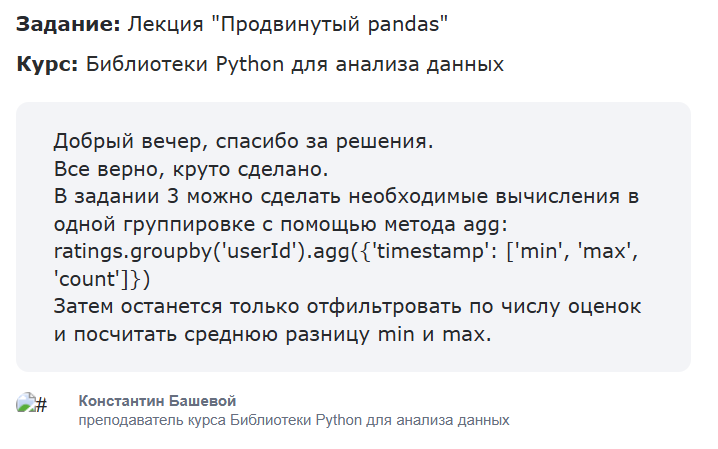

**Задание 3**

Используйте файл с оценками фильмов `ml-latest-small/ratings.csv`. Посчитайте среднее время жизни пользователей, которые выставили более 100 оценок. Под временем жизни понимается разница между максимальным и минимальным значениями столбца `timestamp` для данного значения `userId`.

In [ ]:
import pandas as pd

ratings = pd.read_csv('ratings.csv')
ratings.head()

,userId,movieId,rating,timestamp
0,1,31,2.5,1260759144
1,1,1029,3.0,1260759179
2,1,1061,3.0,1260759182
3,1,1129,2.0,1260759185
4,1,1172,4.0,1260759205


In [ ]:
more_than_100_rtngs = ratings.groupby('userId').agg({'timestamp': ['min', 'max', 'count']})
more_than_100_rtngs = more_than_100_rtngs[more_than_100_rtngs['timestamp']['count'] > 100]
more_than_100_rtngs

timestamp                  
               min         max count
userId                              
4        949778714   949982274   204
8       1154389340  1154474527   116
15       997937239  1469330735  1700
17      1127468587  1127476640   363
19       855190091   855195373   423
...            ...         ...   ...
656      986240991   986244044   128
659      834598040   866207451   142
664     1343731283  1441911722   519
665      992836298  1046967769   434
671     1063500751  1074784735   115

[258 rows x 3 columns]

In [ ]:
average_lifetime = (
    more_than_100_rtngs['timestamp']['max'] - more_than_100_rtngs['timestamp']['min']
    ).mean()
print(f'Средняя разница между min и max timestamp для пользователей с более чем 100 оценками: {average_lifetime:.0f} секунд')

Средняя разница между min и max timestamp для пользователей с более чем 100 оценками: 40080507 секунд
